In [16]:
import torch
import torch.nn.functional as F
from torch.nn import Linear, ReLU
from torch_geometric.nn import GCNConv, global_mean_pool, global_max_pool

class GraphUNet(torch.nn.Module):
    def __init__(self, in_channels=4, base_channels=64, out_channels=3):
        super().__init__()
        
        # Encoder
        self.conv1 = GCNConv(in_channels, base_channels)
        self.conv2 = GCNConv(base_channels, base_channels * 2)
        self.conv3 = GCNConv(base_channels * 2, base_channels * 4)
        self.conv4 = GCNConv(base_channels * 4, base_channels * 8)
        
        # Decoder / Output MLP
        self.lin1 = Linear(base_channels * 8, base_channels * 4)
        self.lin2 = Linear(base_channels * 4, base_channels * 2)
        self.lin3 = Linear(base_channels * 2, out_channels)

    def forward(self, x, edge_index, batch):
        # Encoder
        x = F.relu(self.conv1(x, edge_index))  # [num_nodes, 64]
        x = F.relu(self.conv2(x, edge_index))  # [num_nodes, 128]
        x = F.relu(self.conv3(x, edge_index))  # [num_nodes, 256]
        x = F.relu(self.conv4(x, edge_index))  # [num_nodes, 512]

        # Global pooling over graph
        #x = global_mean_pool(x, batch)         # [batch_size, 512]

        # Decoder (MLP)
        x = F.relu(self.lin1(x))               # [batch_size, 256]
        x = F.relu(self.lin2(x))               # [batch_size, 128]
        x = self.lin3(x)                       # [batch_size, 3]

        return x


In [17]:
import pandas as pd
from torch_geometric.data import Data
from torch_geometric.loader import DataLoader as GeoDataLoader

class RNAGraphDataset(torch.utils.data.Dataset):
    def __init__(self, df):
        self.graphs = []
        mapping = {'A': [1, 0, 0, 0], 'U': [0, 1, 0, 0], 'C': [0, 0, 1, 0], 'G': [0, 0, 0, 1]}

        for mol_id, group in df.groupby('mol_id'):
            group = group.sort_values('resid').reset_index(drop=True)
            seq = group['resname'].values
            coords = group[['x_1', 'y_1', 'z_1']].values

            num_nodes = len(seq)
            x = torch.tensor([mapping.get(nuc, [0,0,0,0]) for nuc in seq], dtype=torch.float)  # (num_nodes, 4)
            y = torch.tensor(coords, dtype=torch.float)  # (num_nodes, 3)

            # Construct edge_index for a simple chain (1D sequence → linear chain graph)
            edge_index = torch.tensor([
                [i, i+1] for i in range(num_nodes - 1)
            ] + [
                [i+1, i] for i in range(num_nodes - 1)
            ], dtype=torch.long).T  # shape [2, 2*(num_nodes - 1)]

            data = Data(x=x, edge_index=edge_index, y=y)
            data.mol_id = mol_id
            data.resid = torch.tensor(group['resid'].values, dtype=torch.long)
            data.resname = list(group['resname'].values)
            self.graphs.append(data)

    def __len__(self):
        return len(self.graphs)

    def __getitem__(self, idx):
        return self.graphs[idx]

# Load DataFrame and create DataLoader
df = pd.read_csv('RNA_data.csv')
dataset = RNAGraphDataset(df)
loader = GeoDataLoader(dataset, batch_size=32, shuffle=True)


In [18]:
from torch_geometric.data import Batch
import torch.nn as nn

model = GraphUNet()
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)
criterion = nn.MSELoss()
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
model.to(device)

def tm_score_approx(pred, target, d0=1.24):
    dists = torch.norm(pred - target, dim=-1)  # (total_nodes,)
    score = 1 / (1 + (dists / d0) ** 2)
    return score.mean()

num_epochs = 2
for epoch in range(num_epochs):
    model.train()
    total_loss = 0.0
    total_tm = 0.0

    for batch in loader:
        batch = batch.to(device)
        optimizer.zero_grad()

        # Forward pass
        out = model(batch.x, batch.edge_index, batch.batch)  # shape: (batch_size, 3)

        # Supervised target: global mean coordinates per graph (aggregated from y)
        # y: [num_nodes, 3] → [batch_size, 3]
        y = batch.y
        batch_y = torch.zeros_like(out)
        for i in range(batch.num_graphs):
            mask = batch.batch == i
            batch_y[i] = y[mask].mean(dim=0)

        loss = criterion(out, batch_y)
        loss.backward()
        optimizer.step()

        tm = tm_score_approx(out, batch_y)

        total_loss += loss.item()
        total_tm += tm.item()

    avg_loss = total_loss / len(loader)
    avg_tm = total_tm / len(loader)
    print(f"Epoch {epoch+1}/{num_epochs} - Loss: {avg_loss:.4f}, TM-score ≈ {avg_tm:.4f}")

# Save the model
torch.save(model.state_dict(), 'RNA_gnn.pt')
# Initialize and load the model
model = GraphUNet()
model.load_state_dict(torch.load('RNA_gnn.pt'))
model.eval()  # Set to evaluation mode


Epoch 1/2 - Loss: 110.5766, TM-score ≈ 0.8547
Epoch 2/2 - Loss: 117.3473, TM-score ≈ 0.7479


GraphUNet(
  (conv1): GCNConv(4, 64)
  (conv2): GCNConv(64, 128)
  (conv3): GCNConv(128, 256)
  (conv4): GCNConv(256, 512)
  (lin1): Linear(in_features=512, out_features=256, bias=True)
  (lin2): Linear(in_features=256, out_features=128, bias=True)
  (lin3): Linear(in_features=128, out_features=3, bias=True)
)

In [19]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import pandas as pd
import random
import numpy as np
from collections import defaultdict

# Load the validation file
val_df = pd.read_csv('./data/validation_labels.csv')  # Assuming this is the file name

# Extract base mol_name and res_index
#val_df['mol_base'] = val_df['ID'].apply(lambda x: '_'.join(x.split('_')[:2]))
#val_df['res_index'] = val_df['ID'].apply(lambda x: int(x.split('_')[-1]))
val_df['mol_base'] = val_df['ID'].apply(lambda x: x.split('_')[0])

# Initialize output list
output_rows = []
global_mol_id = 10001  # Use a distinct ID range for validation set

for mol_base, group in val_df.groupby('mol_base'):
    group = group.sort_values('resid').reset_index(drop=True)

    current_segment = []
    prev_resid = None

    for _, row in group.iterrows():
        # Consider -1e+18 as missing (common in your data)
        missing_coords = any([
            np.isclose(row['x_1'], -1e+18),
            np.isclose(row['y_1'], -1e+18),
            np.isclose(row['z_1'], -1e+18)
        ])
        resid_break = (prev_resid is not None and row['resid'] != prev_resid + 1)

        if (resid_break or missing_coords) and current_segment:
            for r in current_segment:
                r['mol_name'] = mol_base
                r['mol_id'] = global_mol_id
                output_rows.append(r)
            global_mol_id += 1
            current_segment = []

        if not missing_coords:
            current_segment.append(row.to_dict())

        prev_resid = row['resid']

    if current_segment:
        for r in current_segment:
            r['mol_name'] = mol_base
            r['mol_id'] = global_mol_id
            output_rows.append(r)
        global_mol_id += 1

# Create final validation DataFrame
final_df = pd.DataFrame(output_rows)
final_df = final_df[['mol_name', 'mol_id', 'resname', 'resid', 'x_1', 'y_1', 'z_1']]

# Save
final_df.to_csv('RNA_val_data.csv', index=False)
val_df = pd.read_csv('RNA_val_data.csv')

import pandas as pd
import random
import torch
from torch.nn import functional as F
import numpy as np
from collections import defaultdict
from torch.utils.data import DataLoader
from torch.nn.utils.rnn import pad_sequence

# Create dataset and dataloader
dataset = RNAGraphDataset(val_df)
loader = GeoDataLoader(dataset, batch_size=32, shuffle=True)

# Now you can use 'loader' in your validation loop

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
model = GraphUNet().to(device)
model.load_state_dict(torch.load('RNA_gnn.pt', map_location=device))
model.eval()

def tm_score_approx(pred, target, d0=1.24):
    dists = torch.norm(pred - target, dim=1)  # (B, L)
    score = 1 / (1 + (dists / d0) ** 2)
    return score.mean()

from torch_geometric.data import Batch

total_loss = 0
total_tm = 0
criterion = torch.nn.MSELoss()

with torch.no_grad():
    for batch in loader:  # PyG DataLoader returns a Batch object
        batch = batch.to(device)

        outputs = model(batch.x, batch.edge_index, batch.batch)  # [num_nodes, 3] or [B, 3] depending on your model

        # If model outputs per-graph embeddings (e.g., [B, 3]):
        y = batch.y
        batch_y = torch.zeros_like(outputs)
        for i in range(batch.num_graphs):
            mask = batch.batch == i
            batch_y[i] = y[mask].mean(dim=0)

        loss = criterion(outputs, batch_y)
        tm = tm_score_approx(outputs, batch_y)

        total_loss += loss.item()
        total_tm += tm.item()

avg_loss = total_loss / len(loader)
avg_tm = total_tm / len(loader)

print(f"Validation Loss: {avg_loss:.4f}")
print(f"Approximate TM-score: {avg_tm:.4f}")



Validation Loss: 54.2637
Approximate TM-score: 0.8483


In [ ]:
import pandas as pd
import torch
from torch_geometric.data import Batch

# Load input CSV
val_seq_df = pd.read_csv('./data/sample_submission.csv')

# Ensure consistent datatypes
val_seq_df['resid'] = val_seq_df['resid'].astype(int)

# Create fallback grouping key from ID (e.g., "id_1_1" -> "id")
if 'mol_base' not in val_seq_df.columns:
    val_seq_df['mol_base'] = val_seq_df['ID'].str.extract(r'(\w+)_')[0]

# Assign mol_id per molecule (grouped by mol_base)
output_rows = []
mol_id_counter = 1
for mol_base, group in val_seq_df.groupby('mol_base'):
    group = group.sort_values('resid').reset_index(drop=True)
    for _, row in group.iterrows():
        r = row.to_dict()
        r['mol_name'] = mol_base
        r['mol_id'] = mol_id_counter
        output_rows.append(r)
    mol_id_counter += 1

# Build DataFrame with mol_id assignments
final_df = pd.DataFrame(output_rows)

# Build dataset for inference
val_dataset = RNAGraphDataset(final_df)  # Make sure RNAGraphDataset attaches mol_id, resid, resname per Data()
graph_list = [g for g in val_dataset]

# Setup device and batch graphs
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
batched_graph = Batch.from_data_list(graph_list).to(device)

# Ensure model is in eval mode
model.eval()

all_preds = []
all_indices = []

with torch.no_grad():
    # Model now returns [total_num_nodes, 3]
    Y_pred = model(batched_graph.x, batched_graph.edge_index, batched_graph.batch)  # per-node prediction

    all_preds = []
    all_indices = []

    node_offset = 0
    for graph in graph_list:
        num_nodes = graph.num_nodes
        mol_id = int(graph.mol_id.item()) if isinstance(graph.mol_id, torch.Tensor) else int(graph.mol_id)

        for j in range(num_nodes):
            # Get residue info
            resid = int(graph.resid[j]) if hasattr(graph, 'resid') else j
            resname = graph.resname[j] if hasattr(graph, 'resname') else 'UNK'

            pred = Y_pred[node_offset + j]
            all_preds.append(pred)
            all_indices.append({
                'mol_id': mol_id,
                'resid': resid,
                'resname': resname,
            })

        node_offset += num_nodes

# Convert predictions to DataFrame
pred_df = pd.DataFrame(all_indices)
pred_tensor = torch.stack(all_preds)
pred_df['x'] = pred_tensor[:, 0].cpu().numpy()
pred_df['y'] = pred_tensor[:, 1].cpu().numpy()
pred_df['z'] = pred_tensor[:, 2].cpu().numpy()

# Merge predictions with original metadata
final = final_df.merge(pred_df, on=['mol_id', 'resname', 'resid'], how='left')

final['x_1'] = final['x']
final['y_1'] = final['y']
final['z_1'] = final['z']

final[['ID', 'resname', 'resid', 'x_1', 'y_1', 'z_1']].to_csv('sample_submission_predicted.csv', index=False)

print("Saved: sample_submission_predicted.csv")


Saved: sample_submission_predicted.csv


Randomly selected molecule: R1190 
Random seed:  49878


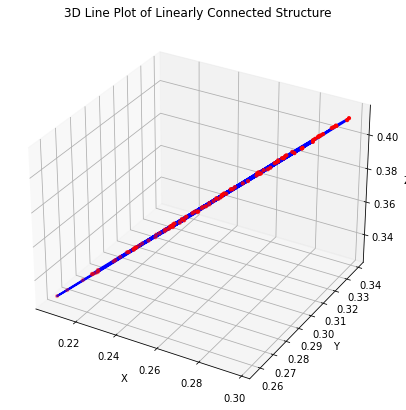

In [21]:
### Plot a random RNA molecule 3D structures
import pandas as pd
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
import numpy as np

# Load the CSV file
df = pd.read_csv('./sample_submission_predicted.csv')

df['mol_prefix'] = df['ID'].str.rsplit('_', n=1).str[0]
unique_molecules = df['mol_prefix'].unique()

#np.random.seed(42)  # 42 is just a commonly used example
seed = np.random.randint(0, 100000)
np.random.seed(seed)

selected_mol = np.random.choice(unique_molecules)
print("Randomly selected molecule:", selected_mol, "\nRandom seed: ", seed)
 
# Filter for rows that belong to molecule 1SCL_A
df_1scl = df[df['ID'].str.startswith(selected_mol)]

# Sort by resid if not already sorted
df = df_1scl.sort_values(by='resid')

# Create a 3D line plot
fig = plt.figure(figsize=(10, 7))
ax = fig.add_subplot(111, projection='3d')

# Plot the line connecting the points
ax.plot(df['x_1'], df['y_1'], df['z_1'], color='blue', linewidth=2)

# Optionally scatter points on top for clarity
ax.scatter(df['x_1'], df['y_1'], df['z_1'], color='red',s=10)

# Axis labels and title
ax.set_xlabel('X')
ax.set_ylabel('Y')
ax.set_zlabel('Z')
ax.set_title('3D Line Plot of Linearly Connected Structure')

fig.savefig('sample_submission_'+selected_mol+'.pdf', format='pdf')
plt.show()


In [22]:
model.eval()

GraphUNet(
  (conv1): GCNConv(4, 64)
  (conv2): GCNConv(64, 128)
  (conv3): GCNConv(128, 256)
  (conv4): GCNConv(256, 512)
  (lin1): Linear(in_features=512, out_features=256, bias=True)
  (lin2): Linear(in_features=256, out_features=128, bias=True)
  (lin3): Linear(in_features=128, out_features=3, bias=True)
)